# ESTIN — Basics of Image Processing
## S4 (DS-AI) · 2025-2026
### Lab 03 — Filtering, Edge Detection & Non-Maxima Suppression

---
> **Images :** `flower.jpg` (grayscale tasks) · `red_bird.png` (colour tasks)  
> **Helper modules :** `tools.py` · `my_functions_tp02.py`

## Imports & Setup

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

import tools                          
import my_functions_tp02 as mf        

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 11, 'figure.titlesize': 13})
print('All imports OK.')

All imports OK.


---
## Part 1 — Averaging & Gaussian Filters

### 1.1 — Load `flower.jpg` in grayscale

Shape : (318, 396)   dtype : float64


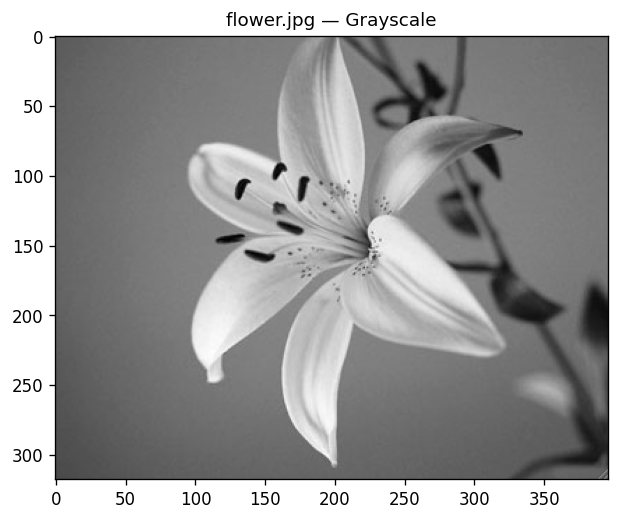

In [42]:
# cv2 flag 0 reads the image in grayscale
flower_gray = cv2.imread('flower.jpg', 0).astype(np.float64)

print(f'Shape : {flower_gray.shape}   dtype : {flower_gray.dtype}')

mf.plot_img(flower_gray, 'flower.jpg — Grayscale')  
plt.show()

### 1.2 — Averaging filter — sizes 3, 7, 11

`get_averaging_filter` is built analogously to `get_gaussian_filtre` from `my_functions_tp02`.  
Filtering is done with **`mf.apply_filter_to_single_channel`** which internally calls  
`tools.add_padding` + `tools.Conv2D`, keeping the output dimensions identical to the input.

kernel  3× 3  →  output shape : (318, 396)  (matches original: True)
kernel  7× 7  →  output shape : (318, 396)  (matches original: True)
kernel 11×11  →  output shape : (318, 396)  (matches original: True)


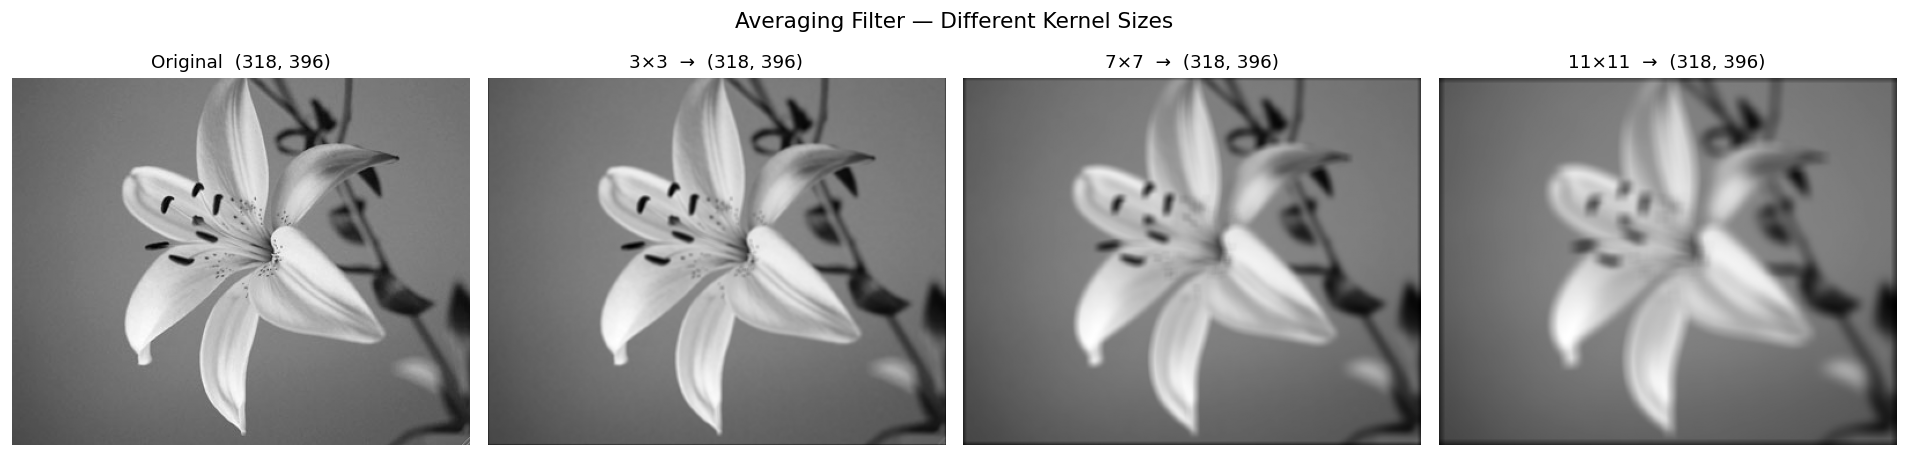

In [43]:
# ── New function — analogous to get_gaussian_filtre ──────────────────────────
def get_averaging_filter(dimension=3):
    """
    Return a normalised box (mean) kernel — analogous to get_gaussian_filtre.
    Each coefficient = 1 / (dimension * dimension).
    """
    kernel = np.ones((dimension, dimension), dtype=np.float64)
    kernel /= kernel.sum()
    return kernel


# ── Apply with mf.apply_filter_to_single_channel for sizes 3, 7, 11 ─────────
filter_sizes = [3, 7, 11]

fig, axes = plt.subplots(1, len(filter_sizes) + 1, figsize=(16, 4))
fig.suptitle('Averaging Filter — Different Kernel Sizes')

axes[0].imshow(flower_gray, cmap='gray')
axes[0].set_title(f'Original  {flower_gray.shape}')
axes[0].axis('off')

for ax, size in zip(axes[1:], filter_sizes):
    kernel   = get_averaging_filter(size)
    # mf.apply_filter_to_single_channel handles padding with tools.add_padding internally
    filtered = mf.apply_filter_to_single_channel(flower_gray, kernel)

    print(f'kernel {size:2d}×{size:2d}  →  output shape : {filtered.shape}  (matches original: {filtered.shape == flower_gray.shape})')

    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'{size}×{size}  →  {filtered.shape}')
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 💬 Comment — Averaging filter sizes

* **3 × 3 :** Very slight blurring — fine details and edges are almost fully preserved.
* **7 × 7 :** Noticeable smoothing — thin structures (stamens, leaf edges) start to blend. Edges are softer.
* **11 × 11 :** Strong blurring — most fine texture is gone; only the main contours remain.

> **Key insight :** The box filter replaces each pixel by the arithmetic mean of its k×k neighbourhood. Larger kernels average over more pixels → stronger blur.  
> Zero-padding (handled by `tools.add_padding` inside `mf.apply_filter_to_single_channel`) ensures the output keeps the **same dimensions** as the input.

### 1.3 — Compare Averaging vs Gaussian (7 × 7) using `mf.filter_analysis`

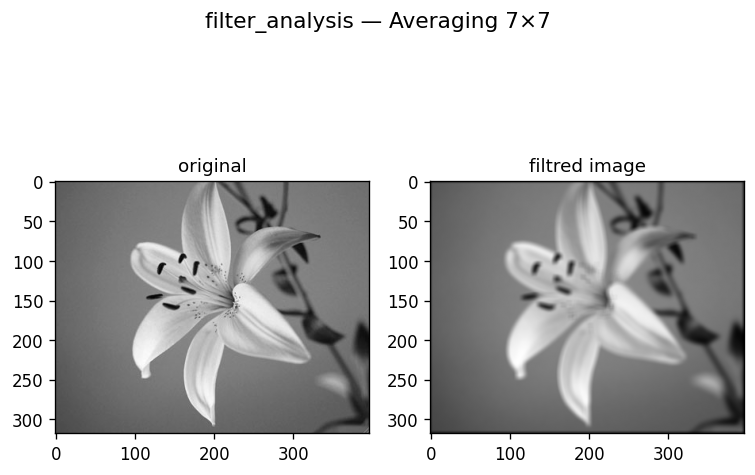

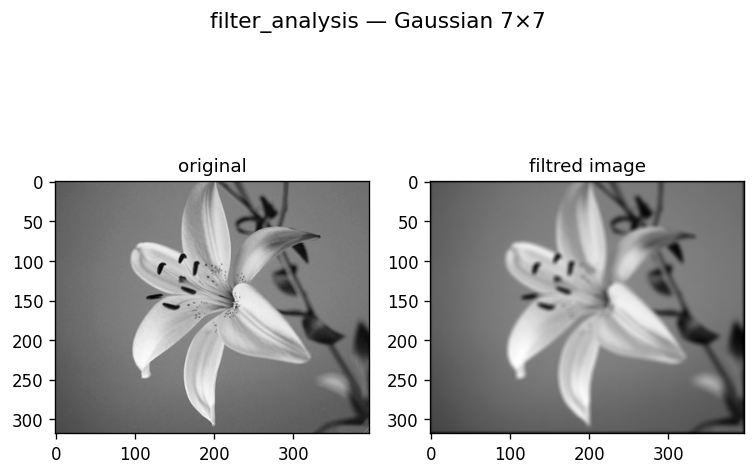

In [44]:
SIZE = 7
kernel_avg   = get_averaging_filter(SIZE)                       # our new function
kernel_gauss = mf.get_gaussian_filtre(dimension=SIZE, sigma=0.5)  # from my_functions_tp02

mf.filter_analysis(flower_gray, kernel_avg)     # directly from my_functions_tp02
plt.suptitle('filter_analysis — Averaging 7×7')
plt.tight_layout()
plt.show()

mf.filter_analysis(flower_gray, kernel_gauss)   # directly from my_functions_tp02
plt.suptitle('filter_analysis — Gaussian 7×7')
plt.tight_layout()
plt.show()

#### 💬 Comment — Averaging vs Gaussian (7 × 7)

| | Averaging (box) | Gaussian |
|---|---|---|
| **Weights** | All neighbours equal | Bell-shaped — central pixels matter more |
| **Blur quality** | Harsh, blocky | Smooth, natural |
| **Edge preservation** | Poor | Better |
| **Noise reduction** | Indiscriminate | Selective |

> **Conclusion :** The Gaussian filter is preferred for pre-processing because it models the assumption that nearer pixels should contribute more. The box filter introduces more visible artefacts at the same kernel size.

### 1.4 — Colour image (`red_bird.png`) using `mf.filter_analysis_colored`

red_bird shape : (152, 204, 3)  (H × W × C)


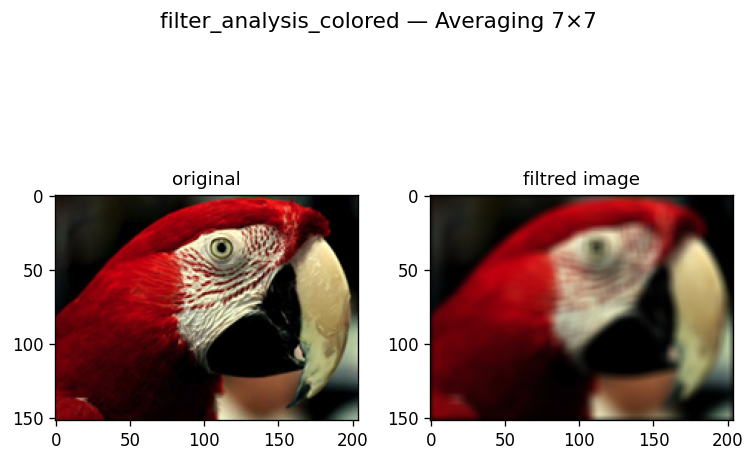

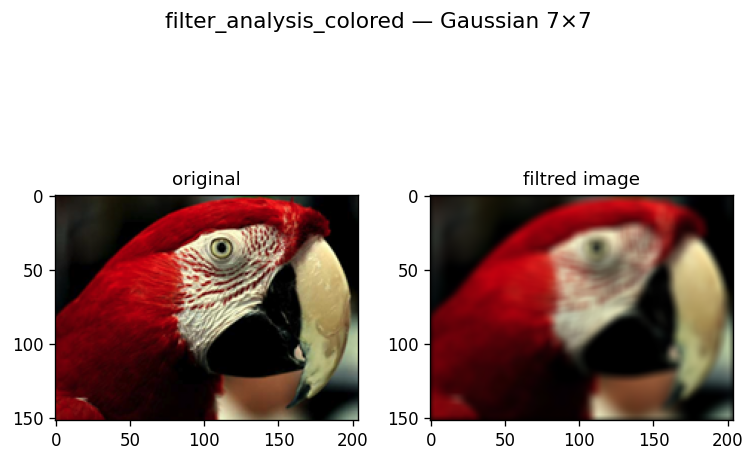

In [45]:
# cv2 loads BGR → convert to RGB for correct matplotlib display
red_bird_bgr = cv2.imread('red_bird.png')
# Normalize float values to [0, 1] so Matplotlib handles the RGB floats correctly
red_bird     = cv2.cvtColor(red_bird_bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0

print(f'red_bird shape : {red_bird.shape}  (H × W × C)')

mf.filter_analysis_colored(red_bird, kernel_avg)     # directly from my_functions_tp02
plt.suptitle('filter_analysis_colored — Averaging 7×7')
plt.tight_layout()
plt.show()

mf.filter_analysis_colored(red_bird, kernel_gauss)   # directly from my_functions_tp02
plt.suptitle('filter_analysis_colored — Gaussian 7×7')
plt.tight_layout()
plt.show()

#### 💬 Comment — Colour filtering

`mf.filter_analysis_colored` calls `mf.apply_filter_to_colored_img` which uses `np.dstack` to apply  
the kernel independently to each R, G, B channel and recombine them. The same observations hold:
* The averaging filter blends colours abruptly.
* The Gaussian gives a smoother, more natural result — the vivid red plumage transitions gradually.

---
## Part 2 — Discrete Filters & Edge Detection

All gradient functions come from **`my_functions_tp02.py`**; orientation utilities from **`tools.py`**.

### 2.1 — Sobel gradients Gx and Gy  —  `mf.get_Gx`, `mf.get_Gy`

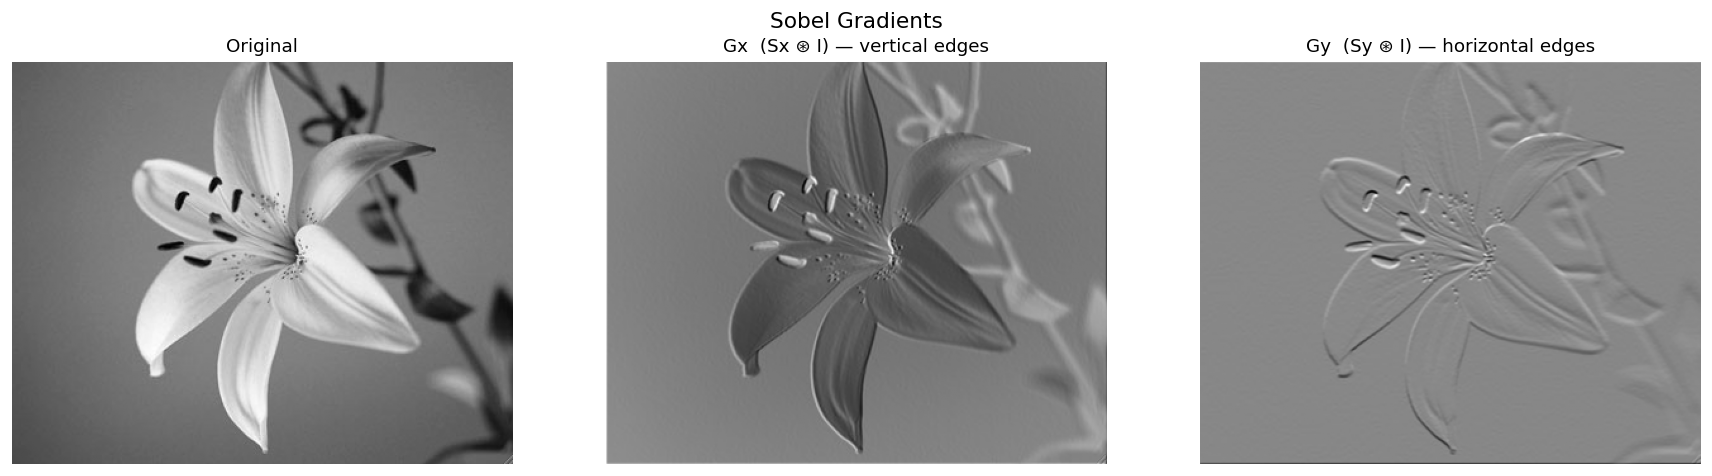

In [46]:
img = flower_gray   # float64 grayscale

Gx = mf.get_Gx(img)    # from my_functions_tp02 → uses apply_filter_to_single_channel(img, Sx)
Gy = mf.get_Gy(img)    # from my_functions_tp02 → uses apply_filter_to_single_channel(img, Sy)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sobel Gradients')

for ax, data, title in zip(
        axes,
        [img, Gx, Gy],
        ['Original', 'Gx  (Sx ⊛ I) — vertical edges', 'Gy  (Sy ⊛ I) — horizontal edges']):
    
    ax.imshow(data, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 💬 Comment — Gx and Gy

* **Gx** highlights **vertical edges** — intensity changes along the horizontal axis. Bright pixels = rising transition, dark = falling.
* **Gy** highlights **horizontal edges** — same logic along the vertical axis.
* Together they capture edge information in all directions.

### 2.2 — Gradient magnitude and direction  —  `mf.module_grad`, `mf.direct_grad`

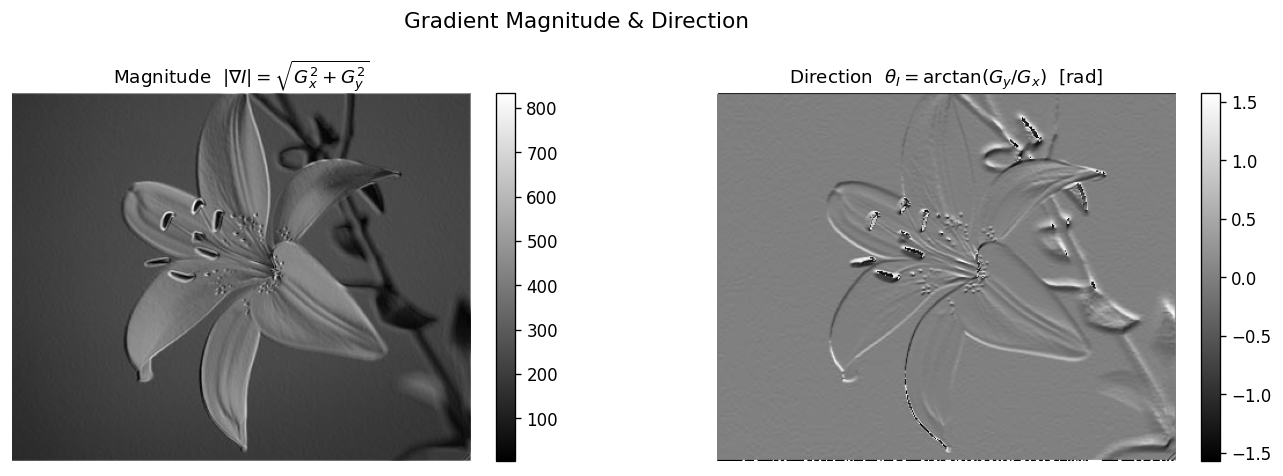

Magnitude range : [3.16, 832.90]
Direction range : [-1.571, 1.571]  rad


In [47]:
G_magnitude = mf.module_grad(img)    # √(Gx² + Gy²)   from my_functions_tp02
G_direction = mf.direct_grad(img)    # arctan(Gy/Gx)   from my_functions_tp02

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Gradient Magnitude & Direction')

im0 = axes[0].imshow(G_magnitude, cmap='gray')
axes[0].set_title(r'Magnitude  $|\nabla I| = \sqrt{G_x^2 + G_y^2}$')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(G_direction, cmap='gray')
axes[1].set_title(r'Direction  $\theta_I = \arctan(G_y / G_x)$  [rad]')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f'Magnitude range : [{G_magnitude.min():.2f}, {G_magnitude.max():.2f}]')
print(f'Direction range : [{np.nanmin(G_direction):.3f}, {np.nanmax(G_direction):.3f}]  rad')

#### 💬 Comment — Magnitude and Direction

* **Magnitude** encodes edge strength — bright pixels correspond to strong transitions (true edges).
* **Direction** gives the angle of the gradient vector perpendicular to the local edge.
* `arctan(Gy/Gx)` produces NaN where Gx = 0 (purely vertical edges). This is handled in the NMS step.

### 2.3 — 8-direction orientation map  —  `tools.grad_orientation`, `tools.cmap_discretize`, `tools.orientation_colors`

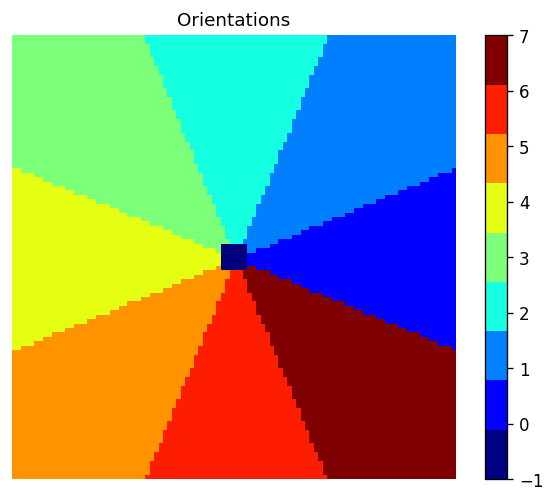

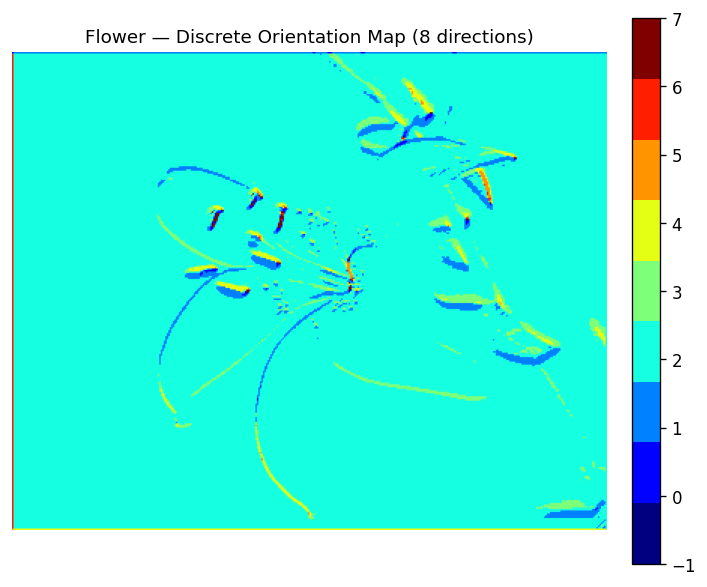

In [55]:
bins = 8
cmap = tools.cmap_discretize('jet', bins + 1)                      # tools.py
g_o  = tools.grad_orientation(Gx, Gy, G_magnitude, b=bins)         # tools.py
ori_map = tools.orientation_colors()                               # tools.py

# Exactly the code block from the assignment
plt.imshow(ori_map, cmap=cmap, vmin=-1, vmax=bins - 1)
plt.colorbar()
plt.axis('off')
plt.title('Orientations')
plt.show()

# Orientation map of the flower
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(g_o, cmap=cmap, vmin=-1, vmax=bins - 1)
ax.set_title('Flower — Discrete Orientation Map (8 directions)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#### 💬 Comment — 8-direction orientation map

Each edge pixel is assigned to the nearest of 8 equally-spaced angular bins (0°, 45°, 90°, …, 315°).  
Non-edge pixels (gradient ≈ 0) are labelled −1. The orientation map is critical for NMS: each pixel  
is compared only to its two neighbours **along its gradient direction**.

### 2.4 — First-order edge detection with thresholding  (uses `mf.module_grad`)

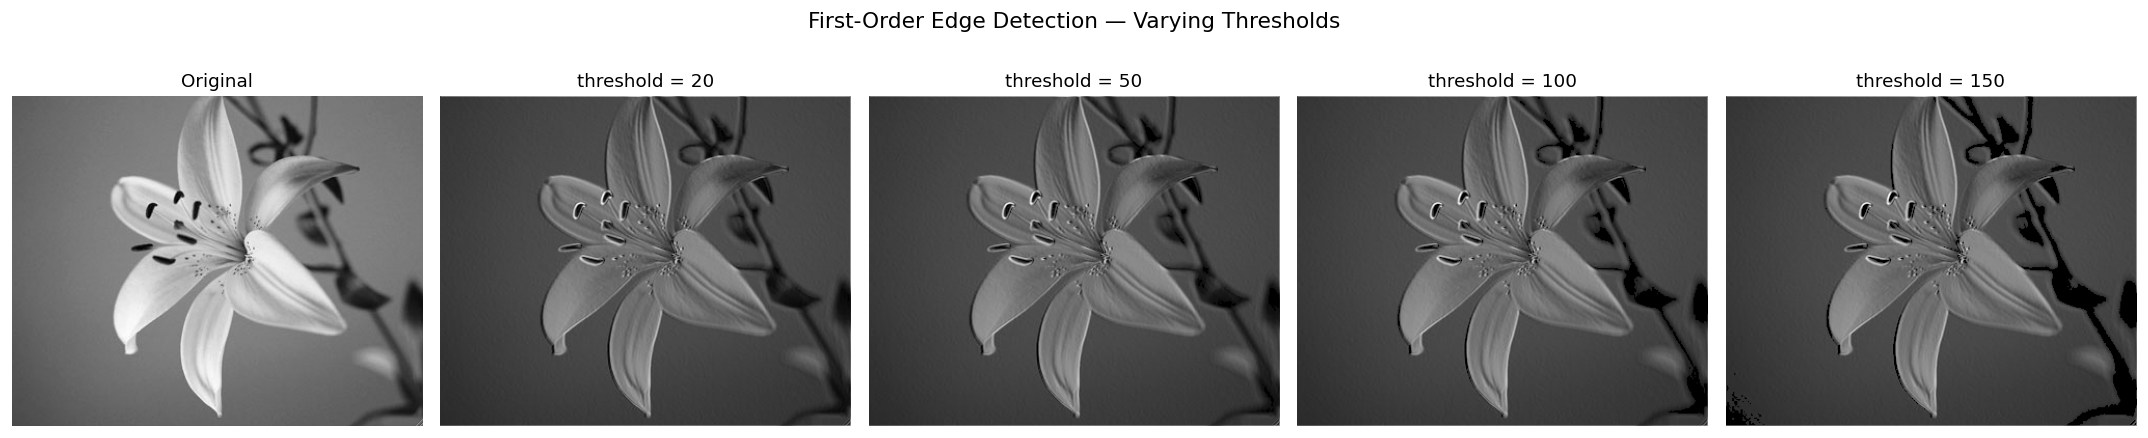

In [49]:
def first_order_edge_detection(img, threshold=50):
    """
    Detect edges using gradient magnitude with a hard threshold.
    Uses mf.module_grad (which calls mf.get_Gx and mf.get_Gy internally).
    """
    magnitude = mf.module_grad(img)                   # from my_functions_tp02
    edge_map  = np.where(magnitude >= threshold, magnitude, 0)
    return edge_map


thresholds = [20, 50, 100, 150]

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(18, 4))
fig.suptitle('First-Order Edge Detection — Varying Thresholds')

# We set vmin=0 so that the background remains pure black, and vmax scales the highest edge
g_max = mf.module_grad(img).max()
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')

for ax, t in zip(axes[1:], thresholds):
    # Setting vmin=0 prevents matplotlib from automatically altering the image contrast
    ax.imshow(first_order_edge_detection(img, t), cmap='gray', vmin=0, vmax=g_max)
    ax.set_title(f'threshold = {t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 💬 Comment — Thresholded edge detection

* **Low threshold (20) :** Over-segmented — noise and texture all pass through.
* **Medium (50–100) :** Best balance — strong structural edges preserved, noise eliminated.
* **High (150) :** Only the sharpest edges survive; many true edges are discarded.

> The optimal threshold is image-dependent. Hysteresis thresholding (used in Canny) avoids this single-threshold sensitivity.

### 2.5 — Laplacian  LI = I ⊛ L  —  `mf.get_L`

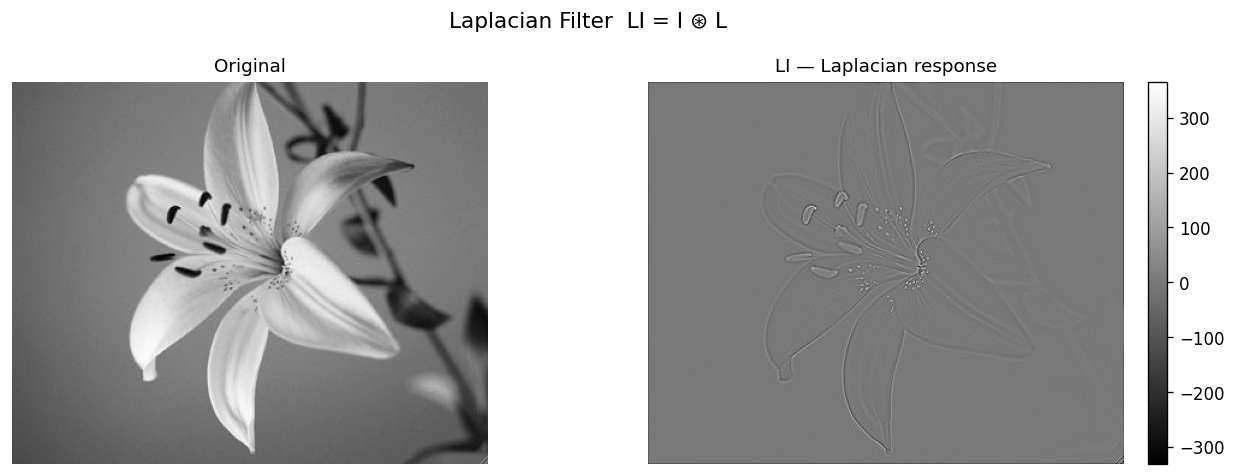

LI range : [-331.00,  365.00]


In [50]:
LI = mf.get_L(img)    # from my_functions_tp02  →  L = [[0,1,0],[1,-4,1],[0,1,0]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Laplacian Filter  LI = I ⊛ L')

axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
im = axes[1].imshow(LI, cmap='gray'); axes[1].set_title('LI — Laplacian response'); axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f'LI range : [{LI.min():.2f},  {LI.max():.2f}]')

#### 💬 Comment — Laplacian

* Approximates the second spatial derivative $\frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$.
* Positive peaks → dark-to-light transitions; negative peaks → light-to-dark.
* **Isotropic**: responds equally to edges in all directions (unlike Sobel which is directional).
* Very sensitive to noise → Gaussian pre-smoothing (LoG) is recommended in practice.

### 2.6 — Zero-crossing detection on LI

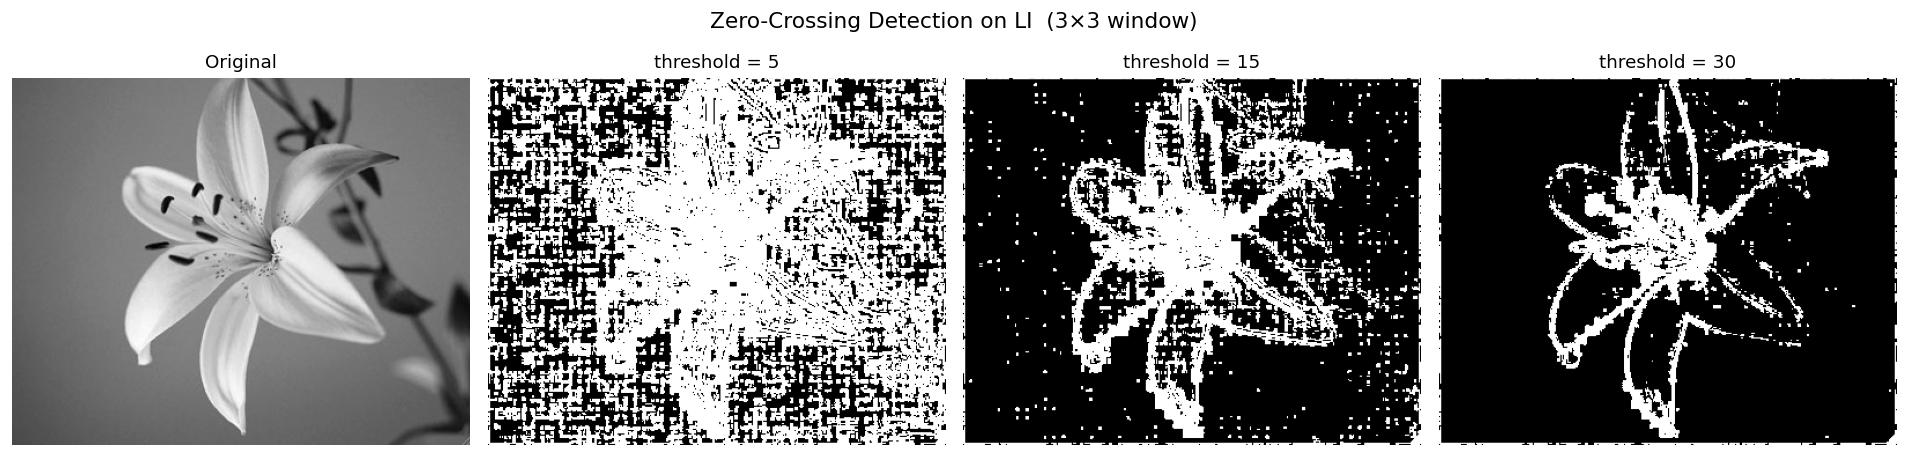

In [51]:
def zero_crossing_detection(LI, threshold=10):
    """
    Detect zero-crossings in the Laplacian response LI.

    Steps (from the assignment):
      1. Take a centred 3×3 window around each pixel (i, j).
      2. Compute max(LI) and min(LI) in the window.
      3. Zero-crossing if  max > 0  AND  min < 0  AND  (max - min) > threshold.
    """
    rows, cols = LI.shape
    edge_map   = np.zeros_like(LI, dtype=np.uint8)
    LI_padded  = np.pad(LI, pad_width=1, mode='edge')

    for i in range(rows):
        for j in range(cols):
            window  = LI_padded[i:i+3, j:j+3]     # step 1
            max_val = window.max()                  # step 2
            min_val = window.min()
            if max_val > 0 and min_val < 0 and (max_val - min_val) > threshold:   # step 3
                edge_map[i, j] = 1

    return edge_map


thresholds_zc = [5, 15, 30]

fig, axes = plt.subplots(1, len(thresholds_zc) + 1, figsize=(16, 4))
fig.suptitle('Zero-Crossing Detection on LI  (3×3 window)')

axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')

for ax, t in zip(axes[1:], thresholds_zc):
    ax.imshow(zero_crossing_detection(LI, t), cmap='gray')
    ax.set_title(f'threshold = {t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 💬 Comment — Zero-crossing

* Zero-crossings locate the **exact position** of an edge (where the second derivative changes sign), giving thinner, more precise results than gradient magnitude thresholding.
* Small threshold (5) → dense map with many noise false positives.
* Large threshold (30) → only the strongest zero-crossings survive.
* Pre-smoothing (LoG = Gaussian + Laplacian) greatly reduces noise sensitivity.

---
## Part 3 — Smoothing & Non-Maxima Suppression (NMS)

### 3.1 — NMS implementation

In [52]:
def non_maxima_suppression(magnitude, direction):
    """
    Non-Maxima Suppression (NMS).

    Input:
        magnitude : 2-D array of gradient magnitudes  (from mf.module_grad)
        direction : 2-D array of gradient directions in radians  (from mf.direct_grad)

    Processing:
        1. Convert angles to degrees in [0°, 180°)  ← necessary conversion
        2. Four regions:
             [0°,  45°) or [157.5°, 180°) → horizontal : compare left / right
             [22.5°, 67.5°)               → diagonal : compare top-right / bottom-left
             [67.5°, 112.5°)              → vertical  : compare top / bottom
             [112.5°, 157.5°)             → diagonal  : compare top-left / bottom-right
        3. Keep pixel only if it is >= both neighbours in its direction.

    Returns:
        I_NMS : 2-D array — thinned edge map
    """
    rows, cols = magnitude.shape
    I_NMS      = np.zeros_like(magnitude)

    # Necessary conversion of calculated angles to degrees in [0°, 180°)
    angle = np.rad2deg(direction) % 180

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if np.isnan(angle[i, j]):
                continue

            a = angle[i, j]

            # Region (0, π/4) → horizontal
            if (0 <= a < 22.5) or (157.5 <= a < 180):
                n1, n2 = magnitude[i, j-1], magnitude[i, j+1]
            # Region (π/4, π/2) → diagonal /
            elif 22.5 <= a < 67.5:
                n1, n2 = magnitude[i-1, j+1], magnitude[i+1, j-1]
            # Region (π/2, 3π/4) → vertical
            elif 67.5 <= a < 112.5:
                n1, n2 = magnitude[i-1, j], magnitude[i+1, j]
            # Region (3π/4, π) → diagonal \
            else:
                n1, n2 = magnitude[i-1, j-1], magnitude[i+1, j+1]

            if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                I_NMS[i, j] = magnitude[i, j]

    return I_NMS


G_mag = mf.module_grad(img)       # from my_functions_tp02
G_dir = mf.direct_grad(img)       # from my_functions_tp02
I_NMS = non_maxima_suppression(G_mag, G_dir)

print(f'Non-zero pixels  —  before NMS : {np.count_nonzero(G_mag)}')
print(f'Non-zero pixels  —  after  NMS : {np.count_nonzero(I_NMS)}')

Non-zero pixels  —  before NMS : 125928
Non-zero pixels  —  after  NMS : 30520


### 3.2 — Compare G and I_NMS

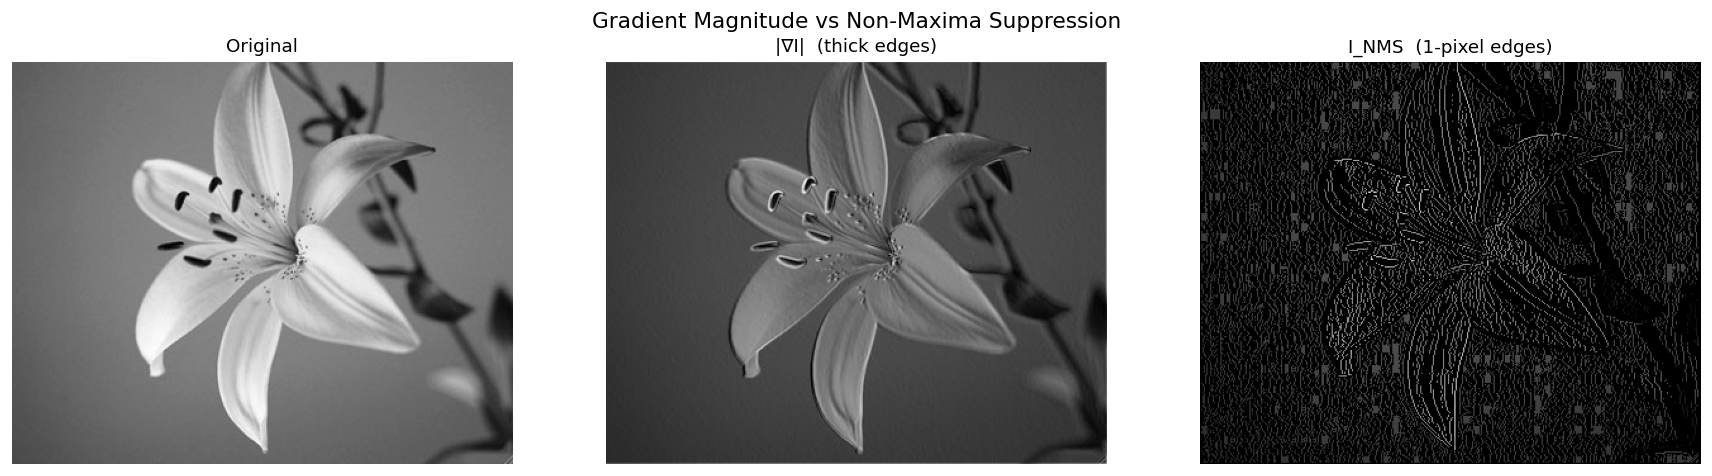

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Gradient Magnitude vs Non-Maxima Suppression')

axes[0].imshow(img,   cmap='gray'); axes[0].set_title('Original');               axes[0].axis('off')
axes[1].imshow(G_mag, cmap='gray');  axes[1].set_title('|∇I|  (thick edges)');    axes[1].axis('off')
axes[2].imshow(I_NMS, cmap='gray');  axes[2].set_title('I_NMS  (1-pixel edges)'); axes[2].axis('off')

plt.tight_layout()
plt.show()

#### 💬 Comment — G vs I_NMS

| | Gradient magnitude $G$ | After NMS ($I_{NMS}$) |
|---|---|---|
| **Edge width** | Thick — several pixels wide | Thin — ideally 1 pixel |
| **Localisation** | Approximate | Precise — gradient ridge peak |
| **Pixel count** | High | Much lower |

> **What we notice :** NMS dramatically sharpens the edge map by keeping only the local maximum of each gradient ridge in the gradient direction. The non-zero pixel count drops significantly. This is the essential thinning step in the Canny detector.

### 3.3 — Effect of smoothing (σ) before and after NMS

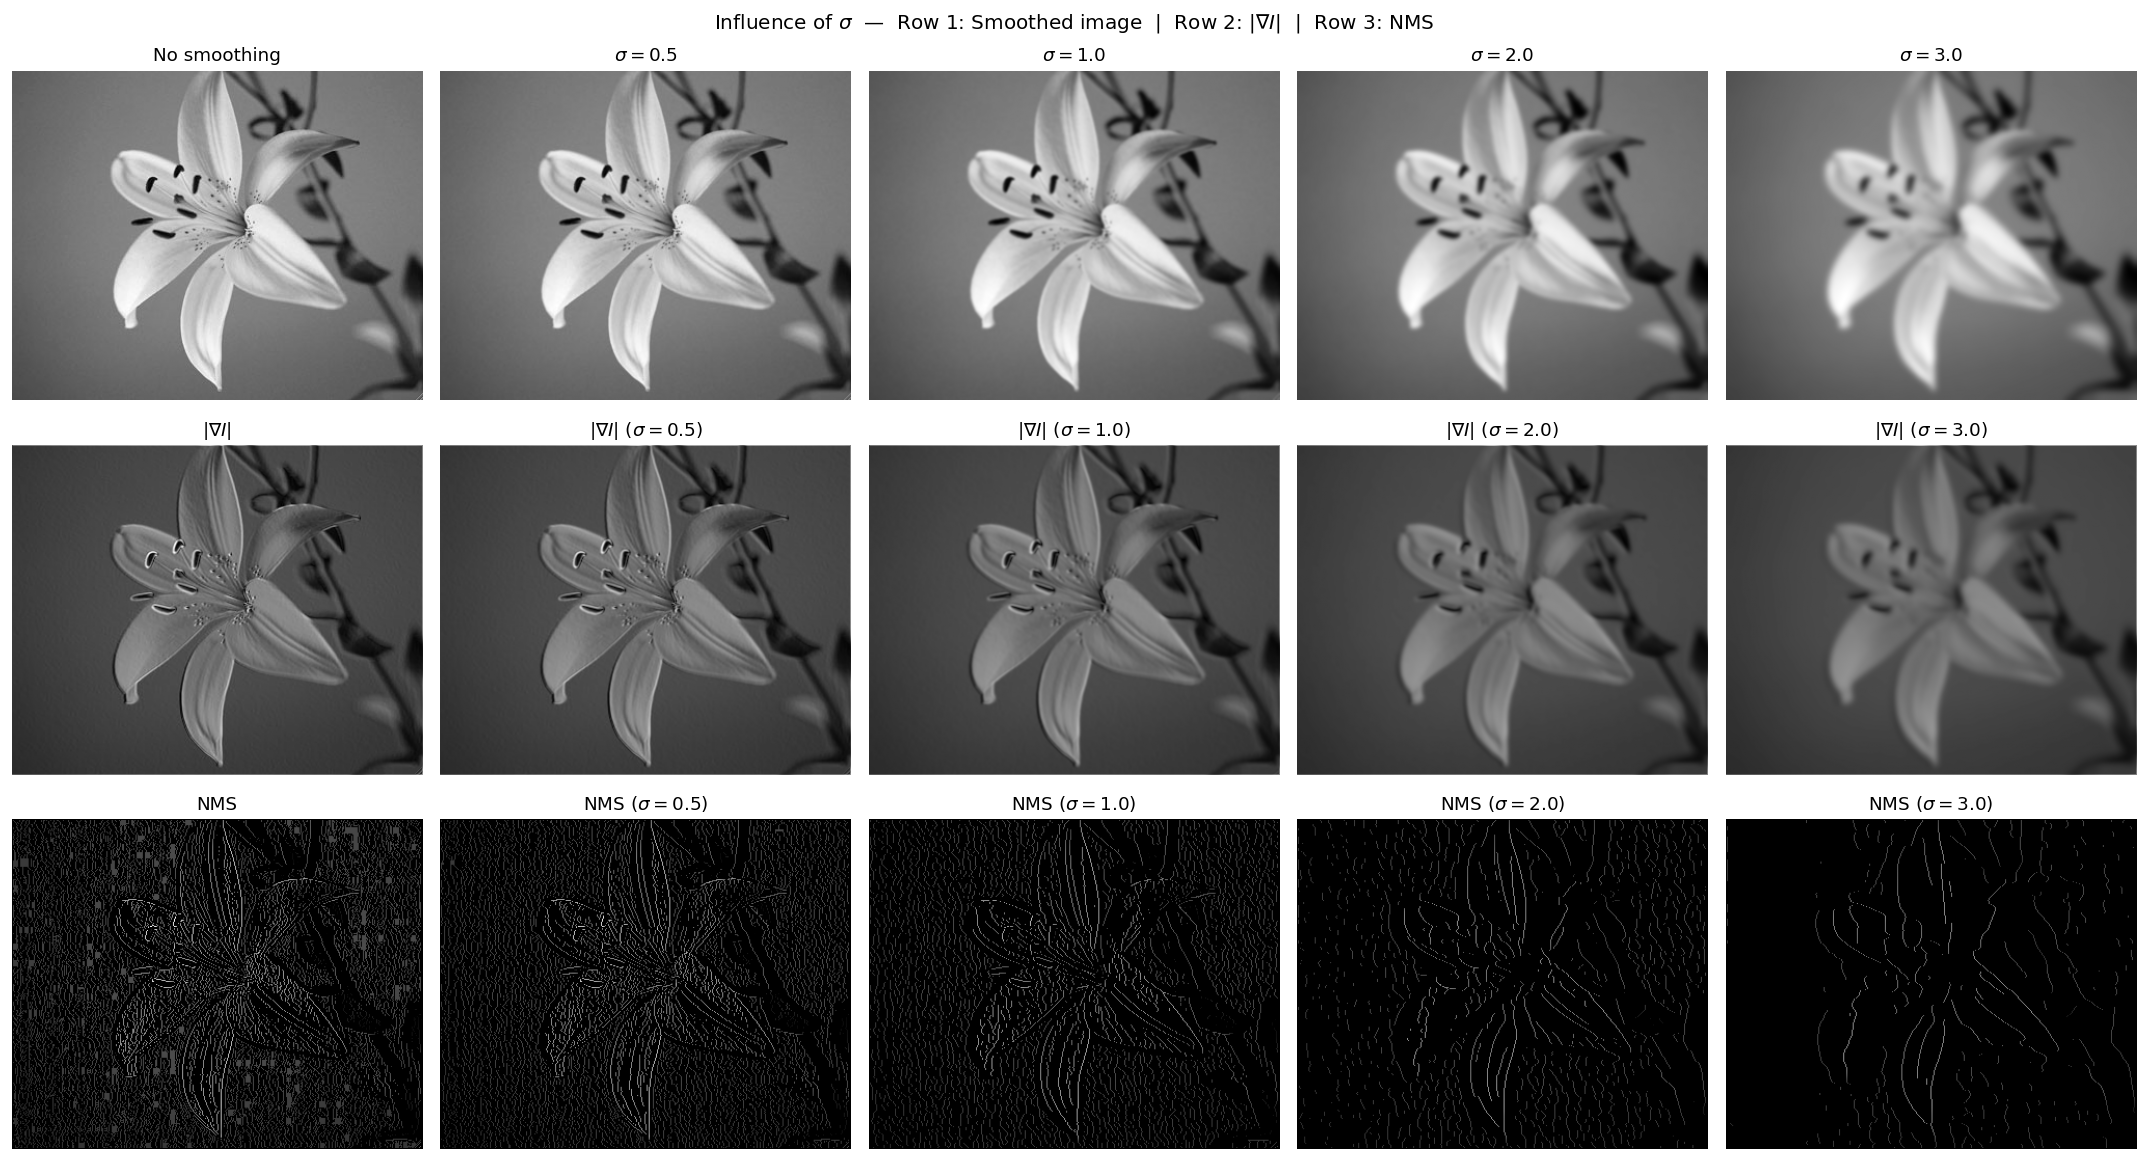

In [ ]:
# scipy.ndimage.gaussian_filter as specified in the assignment
sigmas = [0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(3, len(sigmas) + 1, figsize=(18, 10))
fig.suptitle(
    r'Influence of $\sigma$  —  Row 1: Smoothed image  |  Row 2: $|\nabla I|$  |  Row 3: NMS',
    fontsize=12
)

# Standardise maximum intensity bounds so you actively see the magnitude drop from the blur
mag_vmax = G_mag.max()
nms_vmax = I_NMS.max()

# Column 0 — no smoothing
axes[0, 0].imshow(img,   cmap='gray'); axes[0, 0].set_title('No smoothing'); axes[0, 0].axis('off')
axes[1, 0].imshow(G_mag, cmap='gray', vmin=0, vmax=mag_vmax);  axes[1, 0].set_title(r'$|\nabla I|$');         axes[1, 0].axis('off')
axes[2, 0].imshow(I_NMS, cmap='gray', vmin=0, vmax=nms_vmax);  axes[2, 0].set_title('NMS');           axes[2, 0].axis('off')

for col, sigma in enumerate(sigmas, start=1):
    blurred  = ndimage.gaussian_filter(img, sigma=sigma)   # scipy — from assignment
    G_blur   = mf.module_grad(blurred)                     # my_functions_tp02
    NMS_blur = non_maxima_suppression(G_blur, mf.direct_grad(blurred))   # my_functions_tp02

    axes[0, col].imshow(blurred,  cmap='gray'); axes[0, col].set_title(fr'$\sigma = {sigma}$');     axes[0, col].axis('off')
    # Using fixed vmin=0 preventing edge noise from becoming grey and vmax maintaining absolute scaling
    axes[1, col].imshow(G_blur,   cmap='gray', vmin=0, vmax=mag_vmax);  axes[1, col].set_title(fr'$|\nabla I|$ ($\sigma={sigma}$)'); axes[1, col].axis('off')
    axes[2, col].imshow(NMS_blur, cmap='gray', vmin=0, vmax=nms_vmax);  axes[2, col].set_title(fr'NMS ($\sigma={sigma}$)');  axes[2, col].axis('off')

plt.tight_layout()
plt.show()

---
#### 💬 Comment — Influence of $\sigma$

| $\sigma$ | Smoothed image | $\|\nabla I\|$ | NMS edges |
|---|---|---|---|
| **0 (none)** | Raw | Cluttered, noisy | Fragmented, many false edges |
| **0.5** | Barely blurred | Minor noise reduction | Slight improvement |
| **1.0** | Visibly smooth | Clean gradient, main structures | Well-localised, connected edges |
| **2.0** | Noticeably blurred | Only strong edges survive | Fewer, coarser edges |
| **3.0** | Heavily blurred | Very few structures remain | Only coarsest contours |

> **Conclusion :**  
> $\sigma$ controls the **scale** at which edges are detected:
> - **Small $\sigma$** $\rightarrow$ fine-scale edges, sensitive to noise.  
> - **Large $\sigma$** $\rightarrow$ coarse-scale edges, robust to noise but loses fine detail.  
> 
> Smoothing **before** NMS (i.e. before computing gradients) is the correct approach: it reduces spurious  
> gradient peaks before suppression. Smoothing **after** NMS would blur already-thinned edges unnecessarily.  
> The full pipeline **Gaussian($\sigma$) $\rightarrow$ Sobel $\rightarrow$ NMS $\rightarrow$ Hysteresis thresholding** is the **Canny detector**;  
> $\sigma = 1.0$ typically offers the best trade-off for natural images.

---
## Summary — Functions used

| Section | Function called | Source file |
|---|---|---|
| Plot image | `mf.plot_img` | `my_functions_tp02` |
| Build gaussian kernel | `mf.get_gaussian_filtre` | `my_functions_tp02` |
| Apply single-channel filter | `mf.apply_filter_to_single_channel` | `my_functions_tp02` |
| Grayscale comparison | `mf.filter_analysis` | `my_functions_tp02` |
| Colour comparison | `mf.filter_analysis_colored` | `my_functions_tp02` |
| Sobel Gx | `mf.get_Gx` | `my_functions_tp02` |
| Sobel Gy | `mf.get_Gy` | `my_functions_tp02` |
| Gradient magnitude | `mf.module_grad` | `my_functions_tp02` |
| Gradient direction | `mf.direct_grad` | `my_functions_tp02` |
| Laplacian | `mf.get_L` | `my_functions_tp02` |
| Convolution / padding | `tools.Conv2D`, `tools.add_padding` | `tools` |
| Gaussian kernel | `tools.gaussian_mask` | `tools` |
| Orientation map | `tools.grad_orientation` | `tools` |
| Discrete colormap | `tools.cmap_discretize` | `tools` |
| Colour wheel reference | `tools.orientation_colors` | `tools` |
| Gaussian smoothing | `ndimage.gaussian_filter` | scipy |